In [5]:
#Question 5.2
import numpy as np

filename = input("Enter the filename: ")
x, y = np.loadtxt(filename, unpack=True)

print (f"X array:", x)
print (f"Y array:", y)
print(f"x: Min={x.min()}, Max={x.max()}, Mean={x.mean()}")
print(f"y: Min={y.min()}, Max={y.max()}, Mean={y.mean()}")
y_med = np.median(y)
y2 = (y - y_med)**2

print(f"y_med: {y_med}")
print(f"y2 contents: \n{y2}")

Enter the filename: Week5 q5.2
X array: [ 1.2  2.5  3.7  4.1  5.9  6.3  7.8  8.2  9.5 10. ]
Y array: [10.5 12.1  9.8 11.2 15.4  8.9 13.2 10.1 14.7 11.9]
x: Min=1.2, Max=10.0, Mean=5.92
y: Min=8.9, Max=15.4, Mean=11.78
y_med: 11.55
y2 contents: 
[ 1.1025  0.3025  3.0625  0.1225 14.8225  7.0225  2.7225  2.1025  9.9225
  0.1225]


In [13]:
#Question 5.6
import numpy as np
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
print(np.concatenate((a, b))) 


[1 2 3 4 5 6]


In [11]:
import numpy as np

a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6], [7, 8]])
print(np.concatenate((a, b))) 
print(np.concatenate((a, b), axis=0))
print(np.concatenate((a, b), axis=1))
#axis=0: Increases the number of rows.
#axis=1: Increases the number of columns.

[[1 2]
 [3 4]
 [5 6]
 [7 8]]
[[1 2]
 [3 4]
 [5 6]
 [7 8]]
[[1 2 5 6]
 [3 4 7 8]]


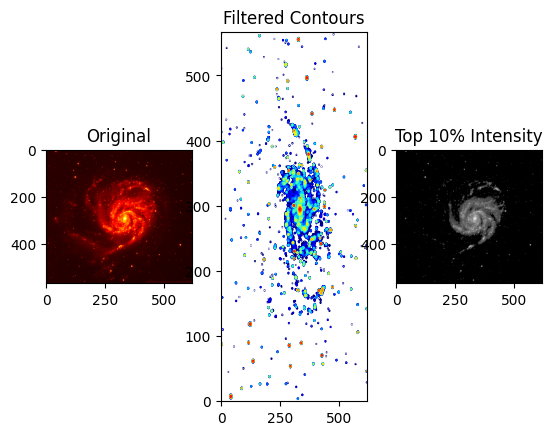

In [33]:
#Question 5.9
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np

img = imageio.imread('m101BW.jpg')

plt.figure()
plt.subplot(1, 3, 1)
plt.imshow(img, cmap='hot')
plt.title("Original")

plt.subplot(1, 3, 2)
plt.contour(img, levels=np.linspace(100, 255, 10), cmap='jet')
plt.title("Filtered Contours")

threshold = np.percentile(img, 90)
high_intensity_img = np.where(img > threshold, img, 0)
plt.subplot(1, 3, 3)
plt.imshow(high_intensity_img, cmap='gray')
plt.title("Top 10% Intensity")


plt.show()

{'Max': 0.0606, 'Min': 0.00482, 'Sum': 0.89154, 'Mean': 0.0222885, 'Std Dev': 0.012699434544498428}


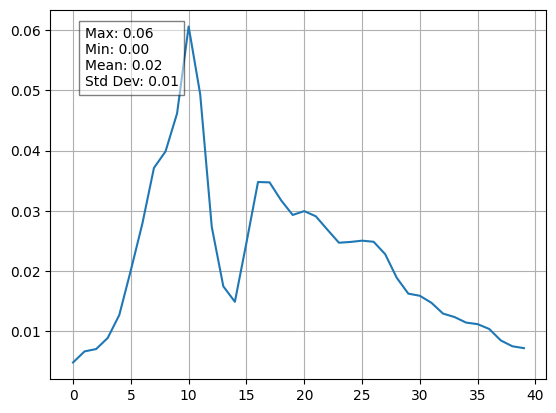

In [20]:
#Question 5.10
import numpy as np
import matplotlib.pyplot as plt

data_flat = np.loadtxt(r'/Users/users/dshah/PROGNUM-repo/Week5/ngc6946.txt')

# 40 planes (z) 50 rows (y) 70 columns (x)
data_3d = data_flat.reshape(40, 50, 70)
z_profile = data_3d[:, 25, 35] #middle

stats = {
    "Max": np.max(z_profile),
    "Min": np.min(z_profile),
    "Sum": np.sum(z_profile),
    "Mean": np.mean(z_profile),
    "Std Dev": np.std(z_profile)
}
print (stats)

stats_text = (f"Max: {stats['Max']:.2f}\n"
              f"Min: {stats['Min']:.2f}\n"
              f"Mean: {stats['Mean']:.2f}\n"
              f"Std Dev: {stats['Std Dev']:.2f}")

plt.text(1, np.max(z_profile), stats_text, 
         fontsize=10, verticalalignment='top', 
         bbox=dict(facecolor='white', alpha=0.5))

plt.plot(z_profile)
plt.grid()
plt.show()

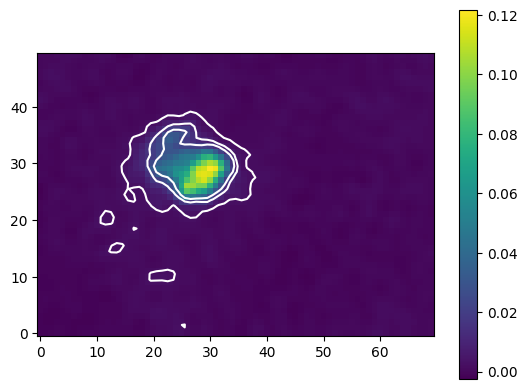

In [24]:
#Question 5.11
import numpy as np
import matplotlib.pyplot as plt

data_flat = np.loadtxt(r'/Users/users/dshah/PROGNUM-repo/Week5/ngc6946.txt')

# 40 planes (z) 50 rows (y) 70 columns (x)
data_3d = data_flat.reshape(40, 50, 70)

first_plane = data_3d[0, :, :]

mean_val = np.mean(first_plane)
std_val = np.std(first_plane)

levels = [mean_val, mean_val + std_val, mean_val + 2 * std_val]

plt.imshow(first_plane, origin='lower')
plt.colorbar()
plt.contour(first_plane, levels=levels, origin='lower', colors='white')
plt.show()

In [25]:
#Question 5.12
import scipy.constants as const

class Galaxy:
    """Class for redshift calculation of galaxies"""
    
    caH_0 = 3968.5  
    c = const.c     # m/s

    def __init__(self, name, calciumHline=caH_0):
        self.name = name
        self.caH = calciumHline

    def redshift(self):
        z = (self.caH - self.caH_0) / self.caH_0
        return z

    def velocity(self):
        v_kms = (self.redshift() * self.c) / 1000 #km/s
        return v_kms

#eg
g = Galaxy("Andromeda", calciumHline=4000.0)
print(f"Galaxy: {g.name}")
print(f"Velocity: {g.velocity()} km/s")

Galaxy: Andromeda
Velocity: 2379.6049960942423 km/s


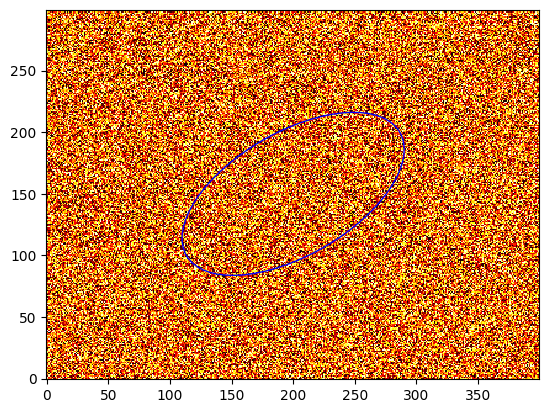

In [31]:
#Question 5.13
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

Nx = 400
Ny = 300
data = np.random.random((Ny, Nx))

fig, ax = plt.subplots()
ax.imshow(data, interpolation='none', origin='lower', cmap='hot')
ellipse = Ellipse(xy=(Nx/2, Ny/2),width=200, height=100, angle=30.0, edgecolor='blue', fc='none')
ax.add_patch(ellipse)

plt.show()